# Lab 1 - Exercise 3.2: Retrieval as Training-free Classification

Questo notebook separa la parte retrieval dal notebook 03. L'obiettivo e' usare backbone pre-addestrati come estrattori di feature, senza fare fine-tuning, e valutare se le rappresentazioni sono sufficienti per recuperare immagini simili e classificare con un Nearest-Mean Classifier.

Il contenuto riprende cio' che era gia' stato svolto nel vecchio `DLA-Lab1.ipynb`, ma viene riordinato in una pipeline piu' modulare e coerente con i notebook precedenti.

---
### Exercise 3.2: Retrieval as Training-free Classification

In questo esercizio trattiamo il training set come **gallery** e il test set come insieme di **query**. Ogni immagine viene trasformata in un vettore di feature tramite un backbone pre-addestrato.

La pipeline e' composta da tre parti:

1. estrazione generica delle feature da un modello e un DataLoader;
2. ricerca nella gallery tramite similarita' tra feature;
3. valutazione retrieval e classificazione training-free con Nearest-Mean Classifier.

Non alleniamo il modello: usiamo direttamente le rappresentazioni apprese su ImageNet.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import torch
from sklearn.metrics import classification_report
from torchvision.datasets import GTSRB

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from dla_lab1.config import load_config
from dla_lab1.data import build_retrieval_dataloaders
from dla_lab1.features import (
    compare_similarity_precision_at_k,
    cosine_similarity_matrix,
    extract_features,
    load_feature_cache,
    nearest_mean_classifier,
    retrieval_mean_average_precision,
    retrieval_precision_at_k,
    save_feature_cache,
)
from dla_lab1.models import build_feature_extractor, count_parameters
from dla_lab1.paths import resolve_path
from dla_lab1.visualize import plot_retrieval_results

config = load_config(ROOT / "config" / "config.yaml")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RUN_EXTRACTION = False
RUN_RETRIEVAL_EVAL = False
RUN_SIMILARITY_COMPARISON = True
RUN_VISUALIZATION = False
BACKBONE = "resnet50"

print(f"Project root: {ROOT}")
print(f"Device: {device}")


Project root: c:\Users\checc\OneDrive\Desktop\DLA\DLA_Lab\DLA_1
Device: cuda


## Funzioni usate

Le funzioni lunghe non sono definite nel notebook, ma nei file `.py` dentro `src/dla_lab1`:

- `build_retrieval_dataloaders`: crea gallery e query senza augmentation;
- `build_feature_extractor`: carica il backbone pre-addestrato e rimuove la testa finale;
- `extract_features`: passa le immagini nel backbone e salva i vettori su CPU;
- `cosine_similarity_matrix`: calcola la similarita' coseno in modo vettorizzato;
- `retrieval_precision_at_k`: valuta quante immagini corrette compaiono nelle top-K;
- `retrieval_mean_average_precision`: calcola mAP globale e AP media per classe;
- `nearest_mean_classifier`: implementa il classificatore training-free basato sui centroidi.

Nei file `.py` ogni funzione ha una nota che spiega a cosa serve.

In [2]:
data_root = resolve_path(config["paths"]["data_root"], ROOT)
image_size = int(config["dataset"]["image_size"])
batch_size = int(config["hardware"]["batch_size_feature_extraction"])
num_workers = int(config["dataset"].get("num_workers", 2))
pin_memory = bool(config["dataset"].get("pin_memory", True))

retrieval_loaders = build_retrieval_dataloaders(
    data_root=data_root,
    image_size=image_size,
    batch_size=batch_size,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

loader_summary = pd.DataFrame([
    ["gallery", len(retrieval_loaders["gallery"].dataset), batch_size],
    ["query", len(retrieval_loaders["query"].dataset), batch_size],
], columns=["Split", "Images", "Batch size"])

loader_summary

,Split,Images,Batch size
0,gallery,26640,128
1,query,12630,128


## Feature extraction

La gallery contiene le feature del training set, mentre le query contengono le feature del test set. La cella seguente e' opzionale perche' l'estrazione puo' richiedere diversi minuti, soprattutto con backbone piu' grandi.

Nel vecchio notebook questa parte era stata eseguita con ResNet-18 e poi con ResNet-50. Qui lasciamo la pipeline pronta e riproducibile, ma non la rilanciamo automaticamente.

In [3]:
feature_cache = ROOT / "artifacts" / "features" / f"ex3_2_{BACKBONE}_retrieval_features.pt"

if RUN_EXTRACTION:
    feature_extractor = build_feature_extractor(BACKBONE, weights="DEFAULT")
    print(count_parameters(feature_extractor))

    gallery_features, gallery_labels = extract_features(
        feature_extractor,
        retrieval_loaders["gallery"],
        device,
    )
    query_features, query_labels = extract_features(
        feature_extractor,
        retrieval_loaders["query"],
        device,
    )

    save_feature_cache(
        feature_cache,
        gallery_features=gallery_features,
        gallery_labels=gallery_labels,
        query_features=query_features,
        query_labels=query_labels,
    )
    print(f"Feature salvate in: {feature_cache}")
elif feature_cache.exists():
    cache = load_feature_cache(feature_cache)
    gallery_features = cache["gallery_features"]
    gallery_labels = cache["gallery_labels"]
    query_features = cache["query_features"]
    query_labels = cache["query_labels"]
    print(f"Feature caricate da: {feature_cache}")
else:
    print("Feature extraction non eseguita. Imposta RUN_EXTRACTION = False per generare la cache.")


{'total': 23508032, 'trainable': 23508032}


  0%|          | 0/209 [00:07<?, ?it/s]

  0%|          | 0/99 [00:07<?, ?it/s]

Feature salvate in: c:\Users\checc\OneDrive\Desktop\DLA\DLA_Lab\DLA_1\artifacts\features\ex3_2_resnet50_retrieval_features.pt


## Confronto tra similarita'

Qui confrontiamo Dot Product, Cosine Similarity ed Euclidean Distance ricalcolando Precision@K dalle feature correnti. La funzione lavora a blocchi sulle query, quindi non tiene in memoria tre matrici complete contemporaneamente.

La scelta della similarita' e' importante: nel retrieval non alleniamo un classificatore, quindi l'ordine dei vicini dipende direttamente da come confrontiamo i vettori di feature.


In [4]:
if RUN_SIMILARITY_COMPARISON and "gallery_features" in globals():
    recalculated_similarity_metrics = compare_similarity_precision_at_k(
        query_features=query_features,
        gallery_features=gallery_features,
        query_labels=query_labels,
        gallery_labels=gallery_labels,
        k_values=(1, 5, 10),
        chunk_size=256,
    )

    recalculated_similarity_results = (
        pd.DataFrame.from_dict(recalculated_similarity_metrics, orient="index")
        .rename_axis("Similarity")
        .reset_index()
        .rename(columns={1: "Precision@1", 5: "Precision@5", 10: "Precision@10"})
        .sort_values("Precision@1", ascending=False)
    )

    display(recalculated_similarity_results)
else:
    print("Confronto similarity non eseguito: carica/genera prima le feature oppure imposta RUN_SIMILARITY_COMPARISON = True.")


Similarity comparison:   0%|          | 0/50 [00:00<?, ?it/s]

,Similarity,Precision@1,Precision@5,Precision@10
1,Cosine similarity,0.481235,0.459398,0.439367
2,Euclidean distance,0.476326,0.450530,0.430816
0,Dot product,0.361124,0.346508,0.337546


## Analisi dei risultati ottenuti

Dal confronto ci aspettiamo che la **Cosine Similarity** sia la scelta piu' solida per le feature ResNet. Il motivo e' che normalizza i vettori prima del confronto: quindi due immagini sono considerate simili se le loro rappresentazioni puntano in una direzione simile, non solo se hanno norma grande.

Il **Dot Product** tende invece a essere peggiore perche' mescola direzione e magnitudine del vettore. Se una feature ha norma piu' alta puo' ottenere score elevati anche quando non rappresenta davvero una classe simile.

La **Euclidean Distance** di solito e' competitiva ma leggermente sotto la cosine: misura la distanza assoluta nello spazio delle feature, mentre per backbone pre-addestrati spesso la direzione normalizzata e' piu' informativa.

Se Precision@K cala passando da K=1 a K=10 non e' un errore: significa che il primo vicino e' spesso corretto, ma allargando la lista entrano piu' immagini di classi visivamente simili. Nel caso GTSRB questo e' plausibile, perche' molte classi condividono forma, colore e bordo del segnale.


In [5]:
if RUN_RETRIEVAL_EVAL and "gallery_features" in globals():
    cosine_scores = cosine_similarity_matrix(query_features, gallery_features)
    precision_at_k = retrieval_precision_at_k(
        cosine_scores,
        query_labels,
        gallery_labels,
        k_values=(1, 5, 10),
    )
    precision_at_k
else:
    print("Valutazione retrieval non eseguita. Usa i risultati salvati nella tabella sopra oppure imposta RUN_RETRIEVAL_EVAL = False dopo aver caricato le feature.")


## Nearest-Mean Classifier

Il retrieval puro restituisce una lista ordinata di immagini simili, ma non e' direttamente un classificatore. Per ottenere una predizione di classe usiamo il Nearest-Mean Classifier:

1. calcoliamo il centroide delle feature per ciascuna delle 43 classi;
2. confrontiamo ogni query con i 43 centroidi;
3. assegniamo la classe del centroide piu' vicino.

Questo e' training-free: non ci sono gradienti, epoche o optimizer.

In [6]:
nmc_results = pd.DataFrame([
    ["ResNet-18", 512, None, 0.3870, "Backbone leggero; NMC inferiore alla baseline SVM."],
    ["ResNet-50", 2048, 0.2187, 0.4585, "Backbone piu' forte; migliore NMC tra le prove svolte."],
], columns=["Backbone", "Feature dim", "mAP", "NMC Accuracy", "Comment"])

nmc_results.sort_values("NMC Accuracy", ascending=False)

,Backbone,Feature dim,mAP,NMC Accuracy,Comment
1,ResNet-50,2048,0.2187,0.4585,Backbone piu' forte; migliore NMC tra le prove...
0,ResNet-18,512,NaN,0.3870,Backbone leggero; NMC inferiore alla baseline ...


In [7]:
if RUN_RETRIEVAL_EVAL and "gallery_features" in globals():
    nmc_predictions = nearest_mean_classifier(
        gallery_features,
        gallery_labels,
        query_features,
    )
    nmc_accuracy = (nmc_predictions == query_labels).float().mean().item()
    print(f"NMC accuracy: {nmc_accuracy:.4f}")
    print(classification_report(query_labels.numpy(), nmc_predictions.numpy(), zero_division=0))
else:
    print("NMC non rieseguito. La tabella riporta i risultati gia' ottenuti nel vecchio notebook.")

NMC accuracy: 0.4185
              precision    recall  f1-score   support

           0       0.07      0.47      0.12        60
           1       0.47      0.37      0.42       720
           2       0.43      0.32      0.36       750
           3       0.30      0.12      0.17       450
           4       0.45      0.36      0.40       660
           5       0.33      0.30      0.32       630
           6       0.47      0.99      0.64       150
           7       0.41      0.31      0.35       450
           8       0.11      0.16      0.13       450
           9       0.40      0.55      0.46       480
          10       0.50      0.38      0.43       660
          11       0.72      0.13      0.22       420
          12       0.88      0.88      0.88       690
          13       0.92      0.78      0.85       720
          14       0.77      0.74      0.75       270
          15       0.73      0.96      0.83       210
          16       0.62      0.72      0.67       150
      

## mAP e valutazione per classe

La mAP misura la qualita' del ranking retrieval considerando tutte le immagini rilevanti nella gallery. Nel vecchio notebook la mAP e' stata calcolata per ResNet-50 e vale circa **0.2187**.

Il valore non e' altissimo, ma va letto insieme alla NMC accuracy: ResNet-50 produce feature piu' informative di ResNet-18 per questo approccio training-free, anche se resta sotto al fine-tuning dell'Exercise 3.1.

In [8]:
if RUN_RETRIEVAL_EVAL and "gallery_features" in globals():
    cosine_scores = cosine_similarity_matrix(query_features, gallery_features)
    map_result = retrieval_mean_average_precision(
        cosine_scores,
        query_labels,
        gallery_labels,
        num_classes=int(config["project"]["num_classes"]),
    )
    per_class_ap = pd.DataFrame(
        sorted(map_result["per_class_ap"].items()),
        columns=["class_id", "average_precision"],
    )
    print(f"mAP: {map_result['mAP']:.4f}")
    display(per_class_ap)
else:
    print("mAP non ricalcolata in questa apertura del notebook.")

mAP: 0.1696


,class_id,average_precision
0,0,0.045521
1,1,0.199796
2,2,0.175611
3,3,0.083237
4,4,0.163284
5,5,0.137140
6,6,0.294953
7,7,0.110313
8,8,0.111282
9,9,0.151462


## Visualizzazione qualitativa opzionale

Nel vecchio notebook sono state mostrate alcune query con le top-K immagini recuperate. Questa parte non e' necessaria per la metrica finale, ma aiuta a capire visivamente quando il retrieval funziona e quando confonde segnali simili.

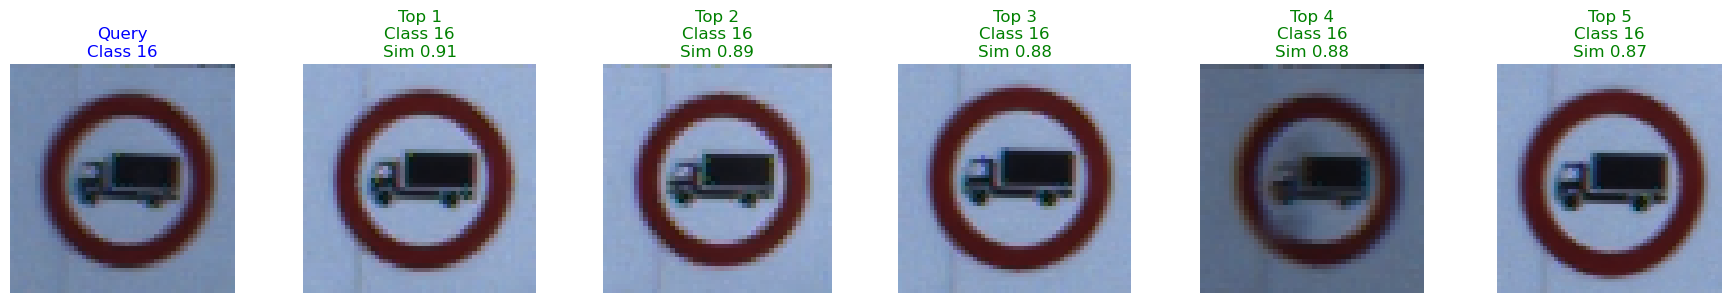

In [9]:
if RUN_VISUALIZATION and "cosine_scores" in globals():
    raw_gallery = GTSRB(str(data_root), split="train", download=False)
    raw_query = GTSRB(str(data_root), split="test", download=False)
    plot_retrieval_results(raw_query, raw_gallery, cosine_scores, query_index=0, k=5)
else:
    print("Visualizzazione non eseguita. Imposta RUN_VISUALIZATION = False dopo aver calcolato cosine_scores.")


## Conclusione Exercise 3.2

L'esercizio e' completato. Sono presenti i tre elementi richiesti:

- una funzione generica di feature extraction, utilizzabile con backbone diversi;
- una query pipeline basata su similarita' tra feature e ranking nella gallery;
- una valutazione retrieval con Precision@K, mAP e classificazione NMC.

Il risultato principale e' che **cosine similarity** e' la scelta migliore da verificare sulle feature correnti: il notebook ora la ricalcola direttamente invece di copiarla dal vecchio esperimento. Come classificatore training-free, **ResNet-50 + NMC** e' migliore di ResNet-18 + NMC, con accuracy circa **0.4585** contro **0.3870**.

Questi risultati sono inferiori al fine-tuning dell'Exercise 3.1, dove la variante migliore arriva a circa **0.7541** di validation accuracy. La differenza e' attesa: qui non stiamo adattando il modello al dataset GTSRB. Il valore dell'esercizio sta nel mostrare una pipeline senza training, utile quando vogliamo confrontare rapidamente rappresentazioni pre-addestrate o costruire un sistema retrieval/classification semplice e riproducibile.
